In [ ]:
!nvidia-smi

Tue Oct  6 13:48:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!python --version

Python 3.13.15


In [ ]:
!pip install nequip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.7/326.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.5/457.5 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 54.2 MB/s eta 0:00:00


In [ ]:
import nequip
print(nequip.__version__)

0.19.1


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'val_100.xyz', 'train_500.xyz', 'sample_data']


In [ ]:
with open("/content/train_500.xyz", "r") as f:
    for i in range(5):
        print(f.readline().rstrip())

52
Lattice="10.638 0.0 0.0 0.0 10.03 0.0 0.0 0.0 30.0" Properties=species:S:1:pos:R:3:forces:R:3 energy=-63896.177329367 pbc="T T T"
C       10.39811872       8.83041321       6.38493052       0.00719597       0.02328287      -0.03864320
O       10.27343322       7.70506139       5.81199910       0.02092094      -0.00903747       0.00999331
O       10.63468870       9.95684035       5.85112334       0.02745541       0.02162582      -0.07240696


In [ ]:
!pip install nequip

In [ ]:
import nequip
print(nequip.__version__)

0.19.1


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
!nequip-train --help

Traceback (most recent call last):
  File "/usr/local/bin/nequip-train", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/hydra/main.py", line 94, in decorated_main
    _run_hydra(
    ~~~~~~~~~~^
        args=args,
        ^^^^^^^^^^
    ...<3 lines>...
        config_name=config_name,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/hydra/_internal/utils.py", line 363, in _run_hydra
    hydra.app_help(config_name=config_name, args_parser=args_parser, args=args)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/hydra/_internal/hydra.py", line 356, in app_help
    cfg = self.compose_config(
        config_name=config_name,
    ...<2 lines>...
        with_log_configuration=True,
    )
  File "/usr/local/lib/python3.13/dist-packages/hydra/_internal/hydra.py", line 594, in compose_config
    cfg = self.config

In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0

data:
  _target_: nequip.data.datamodule.ASEDataModule

  train_file_path: /content/train_500.xyz
  val_file_path: /content/val_100.xyz

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: [C, H, O, Cu]

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: [C, H, O, Cu]
    dataloader_kwargs:
      batch_size: 10


training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel

    seed: 42

    model_dtype: float32

    type_names: [C, H, O, Cu]

    r_max: ${cutoff_radius}

    num_layers: 3

    l_max: 2

    num_features: 32

  loss:
    _target_: nequip.train.EnergyForceLoss

    energy_weight: 1.0
    force_weight: 1.0


trainer:
  _target_: lightning.Trainer

  accelerator: gpu
  devices: 1

  max_epochs: 5

  log_every_n_steps: 10

  default_root_dir: /content/nequip_test
"""

with open("/content/config.yaml", "w") as f:
    f.write(config)

print(config)


run: [train]

cutoff_radius: 5.0

data:
  _target_: nequip.data.datamodule.ASEDataModule

  train_file_path: /content/train_500.xyz
  val_file_path: /content/val_100.xyz

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: [C, H, O, Cu]

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: [C, H, O, Cu]
    dataloader_kwargs:
      batch_size: 10


training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel

    seed: 42

    model_dtype: float32

    type_names: [C, H, O, Cu]

    r_max: ${cutoff_radius}

    num_layers: 3

    l_max: 2

    num_features: 32


In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10


trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10


training_module:
  _target_: nequip.train.EMALightningModule

  loss:
    _target_: nequip.train.EnergyForceLoss
    per_atom_energy: true
    coeffs:
      total_energy: 1.0
      forces: 1.0

  val_metrics:
    _target_: nequip.train.EnergyForceMetrics
    coeffs:
      per_atom_energy_mae: 1.0
      forces_mae: 1.0

  optimizer:
    _target_: torch.optim.Adam
    lr: 0.001


model:
  _target_: nequip.model.NequIPGNNModel

  seed: 42
  model_dtype: float32

  type_names: ${model_type_names}
  r_max: ${cutoff_radius}

  num_layers: 3
  l_max: 2
  num_features: 32
"""

with open("/content/config.yaml", "w") as f:
    f.write(config)

print(config)


run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10


trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10


training_module:
  _target_: nequip.train.EMALightningModule

  loss:
    _target_: n

In [ ]:
from ase.io import read, write

train = read("/content/train_500.xyz", index=":")
val = read("/content/val_100.xyz", index=":")

all_data = train + val

write("/content/small_dataset.xyz", all_data, format="extxyz")

print("Total structures:", len(all_data))

Total structures: 600


In [ ]:
!nequip-train -cp /content -cn config.yaml

[2026-10-06 13:59:51,081][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
Error executing job with overrides: []
Traceback (most recent call last):
  File "/usr/local/bin/nequip-train", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/hydra/main.py", line 94, in decorated_main
    _run_hydra(
    ~~~~~~~~~~^
        args=args,
        ^^^^^^^^^^
    ...<3 lines>...
        config_name=config_name,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/hydra/_internal/utils.py", line 394, in _run_hydra
    _run_app(
    ~~~~~~~~^
        run=args.run,
        ^^^^^^^^^^^^^
    ...<5 lines>...
        overrides=overrides,
        ^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/hydra/_internal/utils.py", line 457, in _run_app
    run_and_report(
    ~~~~~~~~~~~~~~^
        lambda: hydra.run(
        ^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
  

In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10

trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10

training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel
    seed: 42
    model_dtype: float32
    type_names: ${model_type_names}
    r_max: ${cutoff_radius}
    num_layers: 3
    l_max: 2
    num_features: 32

  loss:
    _target_: nequip.train.EnergyForceLoss
    per_atom_energy: true
    coeffs:
      total_energy: 1.0
      forces: 1.0

  val_metrics:
    _target_: nequip.train.EnergyForceMetrics
    coeffs:
      per_atom_energy_mae: 1.0
      forces_mae: 1.0

  optimizer:
    _target_: torch.optim.Adam
    lr: 0.001
"""

with open("/content/config.yaml", "w") as f:
    f.write(config)

print(config)


run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10

trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10

training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: ne

In [ ]:
!nequip-train -cp /content -cn config.yaml

[2026-10-06 14:01:52,664][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
[2026-10-06 14:01:52,667][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 14:01:52,667][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 14:01:52,667][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 14:01:52,667][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 14:01:52,667][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train']
[2026-10-06 14:01:52,667][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /content/outputs/2026-10-06/14-01-52
[2026-10-06 14:01:53,052][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
Error executing job with overrides: []
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/hydra/_i

In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  seed: 42

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10

trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10

training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel
    seed: 42
    model_dtype: float32
    type_names: ${model_type_names}
    r_max: ${cutoff_radius}
    num_layers: 3
    l_max: 2
    num_features: 32

  loss:
    _target_: nequip.train.EnergyForceLoss
    per_atom_energy: true
    coeffs:
      total_energy: 1.0
      forces: 1.0

  val_metrics:
    _target_: nequip.train.EnergyForceMetrics
    coeffs:
      per_atom_energy_mae: 1.0
      forces_mae: 1.0

  optimizer:
    _target_: torch.optim.Adam
    lr: 0.001
"""

with open("/content/config.yaml", "w") as f:
    f.write(config)

print(config)


run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule

  seed: 42

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10

trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10

training_module:
  _target_: nequip.train.EMALightningModule

  model:
    

In [ ]:
!nequip-train -cp /content -cn config.yaml

[2026-10-06 14:02:54,236][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
[2026-10-06 14:02:54,239][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 14:02:54,239][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 14:02:54,239][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 14:02:54,239][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 14:02:54,239][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train']
[2026-10-06 14:02:54,239][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /content/outputs/2026-10-06/14-02-54
[2026-10-06 14:02:54,439][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
[2026-10-06 14:02:54,447][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 validation dat

In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule
  seed: 42

  split_dataset:
    file_path: /content/small_dataset.xyz
    train: 0.8333333333
    val: 0.1666666667

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 10
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 10


trainer:
  _target_: lightning.Trainer
  accelerator: gpu
  devices: 1
  max_epochs: 5
  log_every_n_steps: 10


training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel

    seed: 42
    model_dtype: float32
    type_names: ${model_type_names}
    r_max: ${cutoff_radius}

    num_layers: 3
    l_max: 2
    num_features: 32

    avg_num_neighbors: ${training_data_stats:num_neighbors_mean}

    per_type_energy_scales: ${training_data_stats:per_type_forces_rms}
    per_type_energy_shifts: ${training_data_stats:per_atom_energy_mean}

    per_type_energy_scales_trainable: false
    per_type_energy_shifts_trainable: false

  loss:
    _target_: nequip.train.EnergyForceLoss
    per_atom_energy: true
    coeffs:
      total_energy: 1.0
      forces: 1.0

  val_metrics:
    _target_: nequip.train.EnergyForceMetrics
    coeffs:
      per_atom_energy_mae: 1.0
      forces_mae: 1.0

  optimizer:
    _target_: torch.optim.Adam
    lr: 0.001
"""

with open("/content/config.yaml", "w") as f:
    f.write(config)

print("config.yaml updated")

config.yaml updated


In [ ]:
!nequip-train -cp /content -cn config.yaml

[2026-10-06 14:04:53,191][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
[2026-10-06 14:04:53,193][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 14:04:53,194][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 14:04:53,194][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 14:04:53,194][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 14:04:53,194][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train']
[2026-10-06 14:04:53,194][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /content/outputs/2026-10-06/14-04-53
[2026-10-06 14:04:53,404][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
[2026-10-06 14:04:53,414][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 validation dat

In [ ]:
import os

run_dir = "/content/outputs/2026-10-06/14-04-53"

print(os.listdir(run_dir))

['.hydra', 'train.log']


In [ ]:
import glob
import os

print("=== checkpoint files ===")
for f in glob.glob("/content/**/*.ckpt", recursive=True):
    print(f)

print("\n=== metrics files ===")
for f in glob.glob("/content/**/metrics.csv", recursive=True):
    print(f)

print("\n=== lightning logs ===")
for f in glob.glob("/content/**/lightning_logs*", recursive=True):
    print(f)

=== checkpoint files ===
/content/lightning_logs/version_0/checkpoints/epoch=4-step=500.ckpt

=== metrics files ===

=== lightning logs ===
/content/lightning_logs


In [ ]:
!nequip-evaluate --help

/bin/bash: line 1: nequip-evaluate: command not found


In [ ]:
import shutil

src = "/content/lightning_logs/version_0/checkpoints/epoch=4-step=500.ckpt"
dst = "/content/model.ckpt"

shutil.copy(src, dst)

print(dst)

/content/model.ckpt


In [ ]:
!nequip-package --help

usage: nequip-package [-h] {build,modes,list,diff,update,modify,info} ...

Package NequIP ecosystem models.

options:
  -h, --help            show this help message and exit

commands:
  {build,modes,list,diff,update,modify,info}
    build               build a packaged model file
    modes               list available packaging modes
    list                list files inside a packaged model file
    diff                diff a file inside a packaged model against an
                        installed or local file
    update              replace files in a packaged model and verify
                        predictions are unchanged
    modify              apply a persistent model modifier to a packaged model
    info                get information from a packaged model file


In [ ]:
!nequip-package build --help

usage: nequip-package build [-h] [--mode MODE] ckpt_path output_path

positional arguments:
  ckpt_path    path to checkpoint file
  output_path  output path to save the packaged model. NOTE: a `.nequip.zip`
               extension is mandatory

options:
  -h, --help   show this help message and exit
  --mode MODE  packaging mode controlling which compile modes are included
               (default: nequip)


In [ ]:
!nequip-package build /content/model.ckpt /content/model.nequip.zip

[2026-10-06 14:14:54,483][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 14:14:54,483][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 14:14:54,483][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 14:14:54,483][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 14:14:54,583][nequip.scripts.package][INFO] - [rank: 0] Building `eager` model for packaging ...
[2026-10-06 14:14:54,583][nequip.model.saved_models.load_utils][INFO] - [rank: 0] Loading model from /content/model.ckpt ...
[2026-10-06 14:14:54,583][nequip.model.saved_models.checkpoint][INFO] - [rank: 0] Loading model from checkpoint file: /content/model.ckpt ...
[2026-10-06 14:14:55,567][nequip.train.ema][INFO] - [rank: 0] Loading EMA weights for evaluation model.
[2026-10-06 14:14:55,590][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 val

In [ ]:
import os
print(os.path.exists("/content/model.nequip.zip"))
print(os.path.getsize("/content/model.nequip.zip"))

True
4060809


In [ ]:
!nequip-compile /content/model.nequip.zip /content/model.nequip.pt2 \
  --device cuda \
  --mode aotinductor \
  --target ase

[2026-10-06 14:16:17,581][nequip.scripts.compile][INFO] - [rank: 0] Compiling for device: cuda
[2026-10-06 14:16:17,581][nequip.model.saved_models.load_utils][INFO] - [rank: 0] Loading model from /content/model.nequip.zip ...
[2026-10-06 14:16:17,582][nequip.model.saved_models.package][INFO] - [rank: 0] Loading model from package file: /content/model.nequip.zip ...
/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W1006 14:17:36.279000 8253 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode
W1006 14:17:49.863000 8253 torch/_inductor/ir.py:8256] aten._linalg_det.default is missing a c-shim implementation, using proxy executor as fallback
[2026-10-06 14:21:20,275][nequip.scripts.compile][INFO] - [rank: 0] Exported model saved to /content/model.nequip.pt2


In [ ]:
import os

print(os.path.exists("/content/model.nequip.pt2"))

True


Finished 10/100
Finished 20/100
Finished 30/100
Finished 40/100
Finished 50/100
Finished 60/100
Finished 70/100
Finished 80/100
Finished 90/100
Finished 100/100

VALIDATION RESULTS
Energy MAE:           0.937351 eV
Energy RMSE:          1.058198 eV
Energy MAE / atom:    18.026 meV/atom
Energy RMSE / atom:   20.350 meV/atom
Force MAE:            0.120739 eV/A
Force RMSE:           0.176216 eV/A


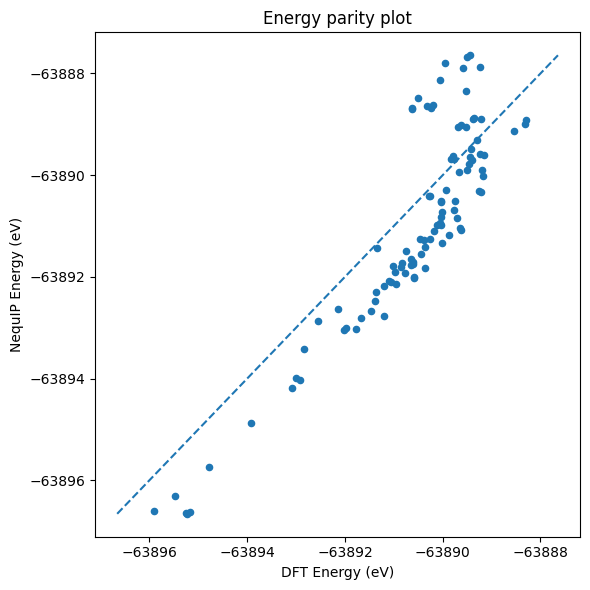

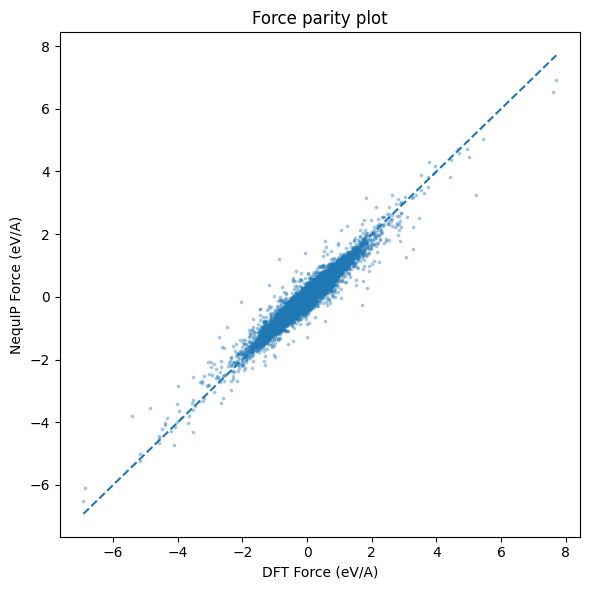

In [ ]:
from ase.io import read
from nequip.integrations.ase import NequIPCalculator
import numpy as np
import matplotlib.pyplot as plt
import torch

# =========================
# 1. 读取验证集
# =========================
val_data = read("/content/val_100.xyz", index=":")

# =========================
# 2. 加载 NequIP 模型
# =========================
calc = NequIPCalculator.from_compiled_model(
    compile_path="/content/model.nequip.pt2",
    device="cuda",
    chemical_species_to_atom_type_map=True
)

# =========================
# 3. 逐个结构预测
# =========================
dft_energies = []
ml_energies = []

dft_forces = []
ml_forces = []

for i, atoms in enumerate(val_data):

    # 保存 DFT 标签
    dft_energy = atoms.get_potential_energy()
    dft_force = atoms.get_forces().copy()

    # 清除原来的 DFT calculator
    atoms.calc = calc

    # MLIP 预测
    ml_energy = atoms.get_potential_energy()
    ml_force = atoms.get_forces()

    dft_energies.append(dft_energy)
    ml_energies.append(ml_energy)

    dft_forces.append(dft_force)
    ml_forces.append(ml_force)

    if (i + 1) % 10 == 0:
        print(f"Finished {i+1}/{len(val_data)}")

# =========================
# 4. 转 numpy
# =========================
dft_energies = np.array(dft_energies)
ml_energies = np.array(ml_energies)

dft_forces = np.concatenate(dft_forces, axis=0)
ml_forces = np.concatenate(ml_forces, axis=0)

# =========================
# 5. 计算 Energy error
# =========================
energy_error = ml_energies - dft_energies

energy_mae = np.mean(np.abs(energy_error))
energy_rmse = np.sqrt(np.mean(energy_error**2))

# 每原子能量误差
n_atoms = len(val_data[0])

energy_mae_per_atom = energy_mae / n_atoms
energy_rmse_per_atom = energy_rmse / n_atoms

# =========================
# 6. Force error
# =========================
force_error = ml_forces - dft_forces

force_mae = np.mean(np.abs(force_error))
force_rmse = np.sqrt(np.mean(force_error**2))

print("\n" + "=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(f"Energy MAE:           {energy_mae:.6f} eV")
print(f"Energy RMSE:          {energy_rmse:.6f} eV")

print(f"Energy MAE / atom:    {energy_mae_per_atom*1000:.3f} meV/atom")
print(f"Energy RMSE / atom:   {energy_rmse_per_atom*1000:.3f} meV/atom")

print(f"Force MAE:            {force_mae:.6f} eV/A")
print(f"Force RMSE:           {force_rmse:.6f} eV/A")

# =========================
# 7. Energy parity plot
# =========================
plt.figure(figsize=(6, 6))

plt.scatter(dft_energies, ml_energies, s=20)

minimum = min(dft_energies.min(), ml_energies.min())
maximum = max(dft_energies.max(), ml_energies.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("DFT Energy (eV)")
plt.ylabel("NequIP Energy (eV)")
plt.title("Energy parity plot")

plt.tight_layout()
plt.savefig(
    "/content/energy_parity.png",
    dpi=300
)

plt.show()

# =========================
# 8. Force parity plot
# =========================

dft_force_flat = dft_forces.flatten()
ml_force_flat = ml_forces.flatten()

plt.figure(figsize=(6, 6))

plt.scatter(
    dft_force_flat,
    ml_force_flat,
    s=3,
    alpha=0.3
)

minimum = min(
    dft_force_flat.min(),
    ml_force_flat.min()
)

maximum = max(
    dft_force_flat.max(),
    ml_force_flat.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("DFT Force (eV/A)")
plt.ylabel("NequIP Force (eV/A)")
plt.title("Force parity plot")

plt.tight_layout()
plt.savefig(
    "/content/force_parity.png",
    dpi=300
)

plt.show()

In [ ]:
from ase.io import read, write

train = read("/content/train.xyz", index=":")
val = read("/content/validation.xyz", index=":")

all_data = train + val

write("/content/formal_dataset.xyz", all_data, format="extxyz")

print("Total:", len(all_data))

Total: 2750


In [ ]:
config = r"""
run: [train]

cutoff_radius: 5.0
model_type_names: [C, H, O, Cu]

data:
  _target_: nequip.data.datamodule.ASEDataModule
  seed: 42

  split_dataset:
    file_path: /content/formal_dataset.xyz
    train: 0.9090909091
    val: 0.0909090909

  transforms:
    - _target_: nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper
      model_type_names: ${model_type_names}

    - _target_: nequip.data.transforms.NeighborListTransform
      r_max: ${cutoff_radius}

  train_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 5
    shuffle: true

  val_dataloader:
    _target_: torch.utils.data.DataLoader
    batch_size: 20
    shuffle: false

  stats_manager:
    _target_: nequip.data.CommonDataStatisticsManager
    type_names: ${model_type_names}
    dataloader_kwargs:
      batch_size: 20


trainer:
  _target_: lightning.Trainer

  accelerator: gpu
  devices: 1
  max_epochs: 100

  log_every_n_steps: 20

  logger:
    _target_: lightning.pytorch.loggers.CSVLogger
    save_dir: ${hydra:runtime.output_dir}
    name: csv_logs

  callbacks:

    - _target_: lightning.pytorch.callbacks.ModelCheckpoint
      dirpath: ${hydra:runtime.output_dir}/checkpoints
      filename: best
      monitor: val0_epoch/forces_mae
      mode: min
      save_top_k: 1
      save_last: true

    - _target_: lightning.pytorch.callbacks.EarlyStopping
      monitor: val0_epoch/forces_mae
      mode: min
      patience: 15
      min_delta: 0.0001


training_module:
  _target_: nequip.train.EMALightningModule

  model:
    _target_: nequip.model.NequIPGNNModel

    seed: 42
    model_dtype: float32

    type_names: ${model_type_names}
    r_max: ${cutoff_radius}

    num_layers: 3
    l_max: 2
    num_features: 32

    avg_num_neighbors: ${training_data_stats:num_neighbors_mean}

    per_type_energy_scales: ${training_data_stats:per_type_forces_rms}
    per_type_energy_shifts: ${training_data_stats:per_atom_energy_mean}

    per_type_energy_scales_trainable: false
    per_type_energy_shifts_trainable: false

  loss:
    _target_: nequip.train.EnergyForceLoss
    per_atom_energy: true
    coeffs:
      total_energy: 1.0
      forces: 1.0

  val_metrics:
    _target_: nequip.train.EnergyForceMetrics
    coeffs:
      per_atom_energy_mae: 1.0
      forces_mae: 1.0

  optimizer:
    _target_: torch.optim.Adam
    lr: 0.001
"""

with open("/content/config_formal.yaml", "w") as f:
    f.write(config)

print("formal config written")

formal config written


In [ ]:
!nequip-train -cp /content -cn config_formal.yaml

[2026-10-06 14:30:03,390][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
[2026-10-06 14:30:03,392][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 14:30:03,392][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 14:30:03,392][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 14:30:03,393][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 14:30:03,393][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train']
[2026-10-06 14:30:03,393][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /content/outputs/2026-10-06/14-30-03
[2026-10-06 14:30:03,599][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
[2026-10-06 14:30:03,608][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 validation dat

In [ ]:
import glob
import os

run_dir = "/content/outputs/2026-10-06/14-30-03"

print("=== Checkpoints ===")
for f in glob.glob(run_dir + "/**/*.ckpt", recursive=True):
    print(f)

print("\n=== CSV files ===")
for f in glob.glob(run_dir + "/**/*.csv", recursive=True):
    print(f)

=== Checkpoints ===
/content/outputs/2026-10-06/14-30-03/checkpoints/best.ckpt
/content/outputs/2026-10-06/14-30-03/checkpoints/last.ckpt

=== CSV files ===
/content/outputs/2026-10-06/14-30-03/csv_logs/version_0/metrics.csv


In [ ]:
import pandas as pd
import glob

csv_files = glob.glob(
    "/content/outputs/2026-10-06/14-30-03/**/*.csv",
    recursive=True
)

print(csv_files)

df = pd.read_csv(csv_files[0])

print("\nColumns:")
print(df.columns.tolist())

print("\nLast rows:")
print(df.tail())

['/content/outputs/2026-10-06/14-30-03/csv_logs/version_0/metrics.csv']

Columns:
['epoch', 'step', 'train_loss_epoch/forces_mse', 'train_loss_epoch/per_atom_energy_mse', 'train_loss_epoch/weighted_sum', 'train_loss_step/forces_mse', 'train_loss_step/per_atom_energy_mse', 'train_loss_step/weighted_sum', 'val0_epoch/forces_mae', 'val0_epoch/forces_maxabserr', 'val0_epoch/forces_rmse', 'val0_epoch/per_atom_energy_mae', 'val0_epoch/per_atom_energy_maxabserr', 'val0_epoch/per_atom_energy_rmse', 'val0_epoch/total_energy_mae', 'val0_epoch/total_energy_maxabserr', 'val0_epoch/total_energy_rmse', 'val0_epoch/weighted_sum']

Last rows:
      epoch   step  train_loss_epoch/forces_mse  \
2700     99  50059                          NaN   
2701     99  50079                          NaN   
2702     99  50099                          NaN   
2703     99  50099                          NaN   
2704     99  50099                     0.003369   

      train_loss_epoch/per_atom_energy_mse  train_loss_epo

In [ ]:
import pandas as pd

metrics_path = "/content/outputs/2026-10-06/14-30-03/csv_logs/version_0/metrics.csv"

df = pd.read_csv(metrics_path)

val_df = df.dropna(subset=["val0_epoch/forces_mae"]).copy()

best_idx = val_df["val0_epoch/forces_mae"].idxmin()
best_row = val_df.loc[best_idx]

print("Best epoch:", int(best_row["epoch"]))
print("Best force MAE:", best_row["val0_epoch/forces_mae"], "eV/A")
print("Force RMSE:", best_row["val0_epoch/forces_rmse"], "eV/A")
print("Energy MAE/atom:", best_row["val0_epoch/per_atom_energy_mae"] * 1000, "meV/atom")
print("Total energy MAE:", best_row["val0_epoch/total_energy_mae"], "eV")

Best epoch: 99
Best force MAE: 0.0484060286247082 eV/A
Force RMSE: 0.0581636394783827 eV/A
Energy MAE/atom: 0.4439090975764 meV/atom
Total energy MAE: 0.0230832730744166 eV


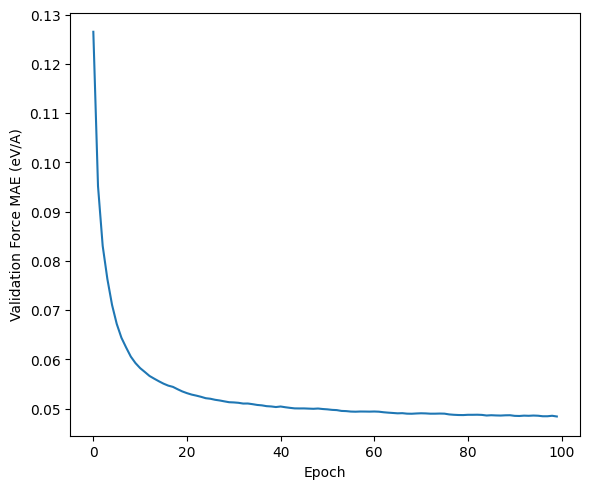

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(
    val_df["epoch"],
    val_df["val0_epoch/forces_mae"]
)

plt.xlabel("Epoch")
plt.ylabel("Validation Force MAE (eV/A)")
plt.tight_layout()
plt.savefig("/content/validation_force_mae.png", dpi=300)
plt.show()

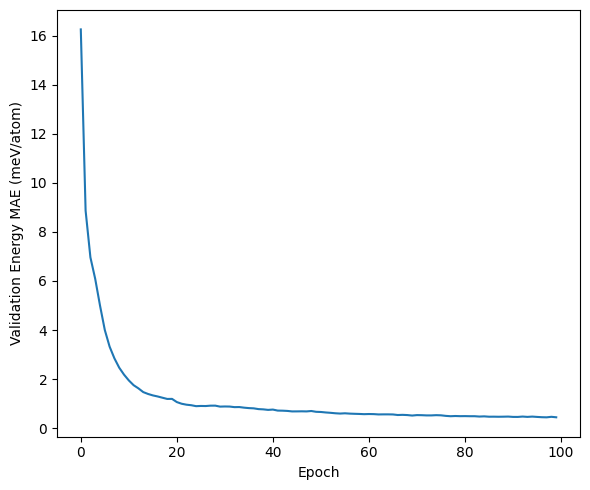

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(
    val_df["epoch"],
    val_df["val0_epoch/per_atom_energy_mae"] * 1000
)

plt.xlabel("Epoch")
plt.ylabel("Validation Energy MAE (meV/atom)")
plt.tight_layout()
plt.savefig("/content/validation_energy_mae.png", dpi=300)
plt.show()

In [ ]:
!nequip-package build \
/content/outputs/2026-10-06/14-30-03/checkpoints/best.ckpt \
/content/best_model.nequip.zip

[2026-10-06 16:11:47,673][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-10-06 16:11:47,673][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu130
[2026-10-06 16:11:47,674][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-10-06 16:11:47,674][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-10-06 16:11:47,770][nequip.scripts.package][INFO] - [rank: 0] Building `eager` model for packaging ...
[2026-10-06 16:11:47,770][nequip.model.saved_models.load_utils][INFO] - [rank: 0] Loading model from /content/outputs/2026-10-06/14-30-03/checkpoints/best.ckpt ...
[2026-10-06 16:11:47,770][nequip.model.saved_models.checkpoint][INFO] - [rank: 0] Loading model from checkpoint file: /content/outputs/2026-10-06/14-30-03/checkpoints/best.ckpt ...
[2026-10-06 16:11:48,723][nequip.train.ema][INFO] - [rank: 0] Loading EMA weights for evaluation model.
[2026-10-06 16:11:48,744][nequip.data.dat

In [ ]:
!nequip-compile \
/content/best_model.nequip.zip \
/content/best_model.nequip.pt2 \
--device cuda \
--mode aotinductor \
--target ase

[2026-10-06 16:12:23,921][nequip.scripts.compile][INFO] - [rank: 0] Compiling for device: cuda
[2026-10-06 16:12:23,921][nequip.model.saved_models.load_utils][INFO] - [rank: 0] Loading model from /content/best_model.nequip.zip ...
[2026-10-06 16:12:23,922][nequip.model.saved_models.package][INFO] - [rank: 0] Loading model from package file: /content/best_model.nequip.zip ...
/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W1006 16:13:37.728000 37594 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode
W1006 16:13:50.496000 37594 torch/_inductor/ir.py:8256] aten._linalg_det.default is missing a c-shim implementation, using proxy executor as fallback
[2026-10-06 16:14:22,744][nequip.scripts.compile][INFO] - [rank: 0] Exported model saved to /content/best_model.nequip.pt2


Number of test structures: 4105
Finished 200/4105
Finished 400/4105
Finished 600/4105
Finished 800/4105
Finished 1000/4105
Finished 1200/4105
Finished 1400/4105
Finished 1600/4105
Finished 1800/4105
Finished 2000/4105
Finished 2200/4105
Finished 2400/4105
Finished 2600/4105
Finished 2800/4105
Finished 3000/4105
Finished 3200/4105
Finished 3400/4105
Finished 3600/4105
Finished 3800/4105
Finished 4000/4105

FINAL TEST RESULTS
Energy MAE:           0.026332 eV
Energy RMSE:          0.042097 eV
Energy MAE / atom:    0.506 meV/atom
Energy RMSE / atom:   0.810 meV/atom
Force MAE:            0.048207 eV/A
Force RMSE:           0.062499 eV/A


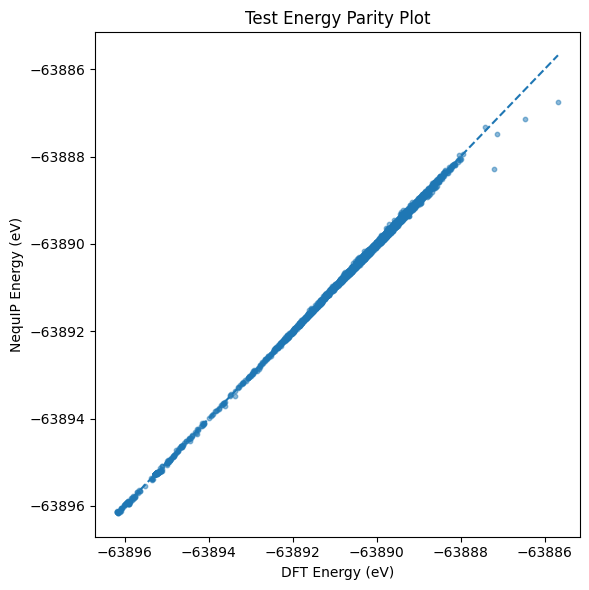

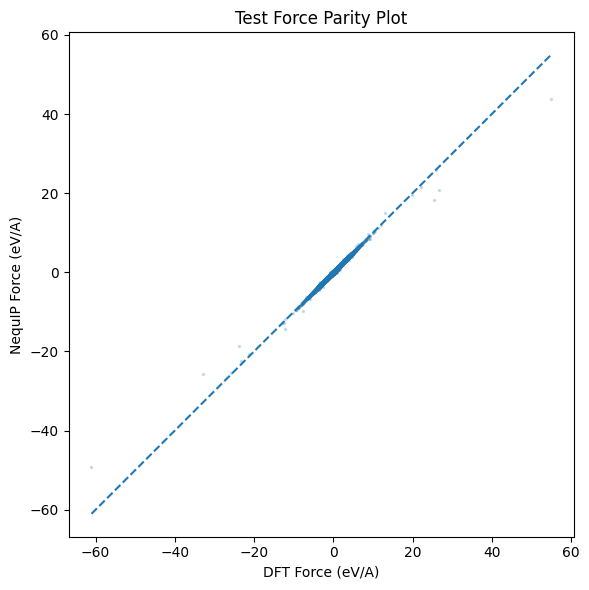

In [ ]:
from ase.io import read
from nequip.integrations.ase import NequIPCalculator
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取 test set
# =========================
test_data = read("/content/test.xyz", index=":")

print("Number of test structures:", len(test_data))

# =========================
# 2. 加载最佳模型
# =========================
calc = NequIPCalculator.from_compiled_model(
    compile_path="/content/best_model.nequip.pt2",
    device="cuda",
    chemical_species_to_atom_type_map=True
)

# =========================
# 3. 预测
# =========================
dft_energies = []
ml_energies = []

dft_forces = []
ml_forces = []

for i, atoms in enumerate(test_data):

    # 原始 DFT 标签
    dft_energy = atoms.get_potential_energy()
    dft_force = atoms.get_forces().copy()

    # 换成 NequIP calculator
    atoms.calc = calc

    ml_energy = atoms.get_potential_energy()
    ml_force = atoms.get_forces()

    dft_energies.append(dft_energy)
    ml_energies.append(ml_energy)

    dft_forces.append(dft_force)
    ml_forces.append(ml_force)

    if (i + 1) % 200 == 0:
        print(f"Finished {i+1}/{len(test_data)}")

# =========================
# 4. 转 numpy
# =========================
dft_energies = np.array(dft_energies)
ml_energies = np.array(ml_energies)

dft_forces = np.concatenate(dft_forces, axis=0)
ml_forces = np.concatenate(ml_forces, axis=0)

# =========================
# 5. Energy errors
# =========================
energy_error = ml_energies - dft_energies

energy_mae = np.mean(np.abs(energy_error))
energy_rmse = np.sqrt(np.mean(energy_error**2))

n_atoms = len(test_data[0])

energy_mae_per_atom = energy_mae / n_atoms
energy_rmse_per_atom = energy_rmse / n_atoms

# =========================
# 6. Force errors
# =========================
force_error = ml_forces - dft_forces

force_mae = np.mean(np.abs(force_error))
force_rmse = np.sqrt(np.mean(force_error**2))

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Energy MAE:           {energy_mae:.6f} eV")
print(f"Energy RMSE:          {energy_rmse:.6f} eV")

print(f"Energy MAE / atom:    {energy_mae_per_atom*1000:.3f} meV/atom")
print(f"Energy RMSE / atom:   {energy_rmse_per_atom*1000:.3f} meV/atom")

print(f"Force MAE:            {force_mae:.6f} eV/A")
print(f"Force RMSE:           {force_rmse:.6f} eV/A")

# =========================
# 7. Energy parity plot
# =========================
plt.figure(figsize=(6,6))

plt.scatter(
    dft_energies,
    ml_energies,
    s=10,
    alpha=0.5
)

minimum = min(dft_energies.min(), ml_energies.min())
maximum = max(dft_energies.max(), ml_energies.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("DFT Energy (eV)")
plt.ylabel("NequIP Energy (eV)")
plt.title("Test Energy Parity Plot")

plt.tight_layout()
plt.savefig(
    "/content/test_energy_parity.png",
    dpi=300
)

plt.show()

# =========================
# 8. Force parity plot
# =========================
dft_force_flat = dft_forces.flatten()
ml_force_flat = ml_forces.flatten()

plt.figure(figsize=(6,6))

plt.scatter(
    dft_force_flat,
    ml_force_flat,
    s=2,
    alpha=0.2
)

minimum = min(
    dft_force_flat.min(),
    ml_force_flat.min()
)

maximum = max(
    dft_force_flat.max(),
    ml_force_flat.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("DFT Force (eV/A)")
plt.ylabel("NequIP Force (eV/A)")
plt.title("Test Force Parity Plot")

plt.tight_layout()
plt.savefig(
    "/content/test_force_parity.png",
    dpi=300
)

plt.show()